# STEP-1: LOADING THE DATASET.

### Step-1.1: 
### Loading the data set for IPL(2023) - Auction Dataset.

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style("whitegrid")
pd.set_option('display.max_columns',None)
pd.set_option('display.width', 1000)

In [35]:
df = pd.read_csv('IPL_Squad_2023_Auction_Dataset.csv')

In [36]:
df.head()

,Unnamed: 0,Player's List,Base Price,TYPE,COST IN ₹ (CR.),Cost IN $ (000),2022 Squad,Team
0,0,Shivam Mavi,4000000,BOWLER,6.0,720.0,KKR,Gujarat Titans
1,1,Joshua Little,5000000,BOWLER,4.4,528.0,NaN,Gujarat Titans
2,2,Kane Williamson,20000000,BATSMAN,2.0,240.0,SRH,Gujarat Titans
3,3,K.S. Bharat,2000000,WICKETKEEPER,1.2,144.0,DC,Gujarat Titans
4,4,Mohit Sharma,5000000,BOWLER,0.5,60.0,NaN,Gujarat Titans


In [37]:
df.tail()

,Unnamed: 0,Player's List,Base Price,TYPE,COST IN ₹ (CR.),Cost IN $ (000),2022 Squad,Team
563,563,Dhruv Patel,2000000,ALL-ROUNDER,NaN,NaN,NaN,Unsold
564,564,Jack Prestwidge,2000000,ALL-ROUNDER,NaN,NaN,NaN,Unsold
565,565,Aditya Sarvate,2000000,ALL-ROUNDER,NaN,NaN,NaN,Unsold
566,566,Sagar Solanki,2000000,ALL-ROUNDER,NaN,NaN,NaN,Unsold
567,567,Prenelan Subrayen,2000000,ALL-ROUNDER,NaN,NaN,NaN,Unsold


In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 568 entries, 0 to 567
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       568 non-null    int64  
 1   Player's List    568 non-null    object 
 2   Base Price       568 non-null    object 
 3   TYPE             568 non-null    object 
 4   COST IN ₹ (CR.)  243 non-null    float64
 5   Cost IN $ (000)  243 non-null    float64
 6   2022 Squad       230 non-null    object 
 7   Team             568 non-null    object 
dtypes: float64(2), int64(1), object(5)
memory usage: 35.6+ KB


In [39]:
df.describe()

,Unnamed: 0,COST IN ₹ (CR.),Cost IN $ (000)
count,568.000000,243.000000,243.000000
mean,283.500000,0.687243,82.469136
std,164.111751,2.511700,301.404032
min,0.000000,0.000000,0.000000
25%,141.750000,0.000000,0.000000
50%,283.500000,0.000000,0.000000
75%,425.250000,0.200000,24.000000
max,567.000000,18.500000,2220.000000


In [40]:
print("Step 1.1 Done ✅")
print("Raw Shape:", df.shape)

Step 1.1 Done ✅
Raw Shape: (568, 8)


### Step-1.2: 
### Drop extra index column if it exists.

In [41]:
# Drop any 'Unnamed' columns
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

print("Step 1.2 Done ✅")
print("Shape after dropping Unnamed:", df.shape)

Step 1.2 Done ✅
Shape after dropping Unnamed: (568, 7)


### Step-1.3: 
### Clean column names.

In [42]:
df.columns = df.columns.str.strip() \
                       .str.replace(' ', '_') \
                       .str.replace("'", '') \
                       .str.replace('₹', 'INR') \
                       .str.replace('$', 'USD') \
                       .str.replace('(', '') \
                       .str.replace(')', '') \
                       .str.replace('.', '')

### Step-1.4: 
### Rename to simple names.

In [43]:
df = df.rename(columns={
    'Players_List': 'Player',
    'TYPE': 'Role', 
    'COST_IN_INR_CR': 'Sold_Price_Cr',
    'Cost_IN_USD_000': 'Cost_USD_000',
    '2022_Squad': 'Previous_Team'
})

print("CELL 1 DONE ✅")
print("Shape:", df.shape)
print("Columns:", list(df.columns))
print("\nFirst 5 rows:")
print(df.head())

CELL 1 DONE ✅
Shape: (568, 7)
Columns: ['Player', 'Base_Price', 'Role', 'Sold_Price_Cr', 'Cost_USD_000', 'Previous_Team', 'Team']

First 5 rows:
            Player Base_Price          Role  Sold_Price_Cr  Cost_USD_000 Previous_Team            Team
0      Shivam Mavi    4000000        BOWLER            6.0         720.0           KKR  Gujarat Titans
1    Joshua Little    5000000        BOWLER            4.4         528.0           NaN  Gujarat Titans
2  Kane Williamson   20000000       BATSMAN            2.0         240.0           SRH  Gujarat Titans
3      K.S. Bharat    2000000  WICKETKEEPER            1.2         144.0            DC  Gujarat Titans
4     Mohit Sharma    5000000        BOWLER            0.5          60.0           NaN  Gujarat Titans


# STEP 2: DATA CLEANING
### Step-2.1: 
### Add Retained/Unsold Flags + Convert Data Types

In [44]:
# 1. Flags for special cases
df['Is_Retained'] = df['Base_Price'].astype(str).str.contains('Retained', case=False, na=False)
df['Is_Unsold'] = df['Team'].astype(str).str.contains('Unsold', case=False, na=False)

# 2. Convert to numbers
df['Base_Price'] = pd.to_numeric(df['Base_Price'], errors='coerce')
df['Sold_Price_Cr'] = pd.to_numeric(df['Sold_Price_Cr'], errors='coerce')
df['Cost_USD_000'] = pd.to_numeric(df['Cost_USD_000'], errors='coerce')

# 3. Fixing Retained players price, Base_Price = Sold_Price_Cr * 1 Crore
df.loc[df['Is_Retained'] == True, 'Base_Price'] = df['Sold_Price_Cr'] * 10000000

print("CELL 2 DONE ✅")
print("\nData types:")
print(df.dtypes)
print("\nRetained count:", df['Is_Retained'].sum())
print("Unsold count:", df['Is_Unsold'].sum())

CELL 2 DONE ✅

Data types:
Player            object
Base_Price       float64
Role              object
Sold_Price_Cr    float64
Cost_USD_000     float64
Previous_Team     object
Team              object
Is_Retained         bool
Is_Unsold           bool
dtype: object

Retained count: 163
Unsold count: 325


### Step-2.2: 
### Handle Missing Values

In [45]:
# Sub-step 1: Fill Previous_Team
df['Previous_Team'] = df['Previous_Team'].fillna('No Team')

# Sub-step 2: For Unsold players, make prices = 0
df.loc[df['Is_Unsold'] == True, ['Sold_Price_Cr', 'Cost_USD_000']] = 0

# Sub-step 3: Fill remaining NaN with 0
df[['Sold_Price_Cr', 'Cost_USD_000', 'Base_Price']] = df[['Sold_Price_Cr', 'Cost_USD_000', 'Base_Price']].fillna(0)

print("Step 2.2 Done ✅")
print("\nMissing values after cleaning:")
print(df.isnull().sum())

Step 2.2 Done ✅

Missing values after cleaning:
Player           0
Base_Price       0
Role             0
Sold_Price_Cr    0
Cost_USD_000     0
Previous_Team    0
Team             0
Is_Retained      0
Is_Unsold        0
dtype: int64


### Step-2.3:
### Feature Engineering

In [46]:
# Sub-step 1: Base Price in Crores for easy comparison
df['Base_Price_Cr'] = df['Base_Price'] / 10000000

# Sub-step 2: Profit/Loss for team = Sold Price - Base Price
df['Profit_Loss_Cr'] = df['Sold_Price_Cr'] - df['Base_Price_Cr']

# Sub-step 3: Category = Role, for groupby later
df['Category'] = df['Role']

print("CELL 2.3 DONE ✅")
print("\nSample with new columns:")
print(df[['Player', 'Base_Price_Cr', 'Sold_Price_Cr', 'Profit_Loss_Cr', 'Is_Retained', 'Is_Unsold']].head(10))

CELL 2.3 DONE ✅

Sample with new columns:
            Player  Base_Price_Cr  Sold_Price_Cr  Profit_Loss_Cr  Is_Retained  Is_Unsold
0      Shivam Mavi            0.4            6.0             5.6        False      False
1    Joshua Little            0.5            4.4             3.9        False      False
2  Kane Williamson            2.0            2.0             0.0        False      False
3      K.S. Bharat            0.2            1.2             1.0        False      False
4     Mohit Sharma            0.5            0.5             0.0        False      False
5      Odean Smith            0.5            0.5             0.0        False      False
6      Urvil Patel            0.2            0.2             0.0        False      False
7    Rahul Tewatia            0.0            0.0             0.0         True      False
8  Pradeep Sangwan            0.0            0.0             0.0         True      False
9      Rashid Khan            0.0            0.0             0.0    

# STEP-3:  Exploratory Data Analysis(EDA) + Data Visulalization Charts

## Step-3.1:
### Bar Chart:
##### Top 10 Most Expensive Players.

C:\Users\shrey\AppData\Local\Temp\ipykernel_38052\1906189056.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top10, x='Sold_Price_Cr', y='Player', palette='viridis')


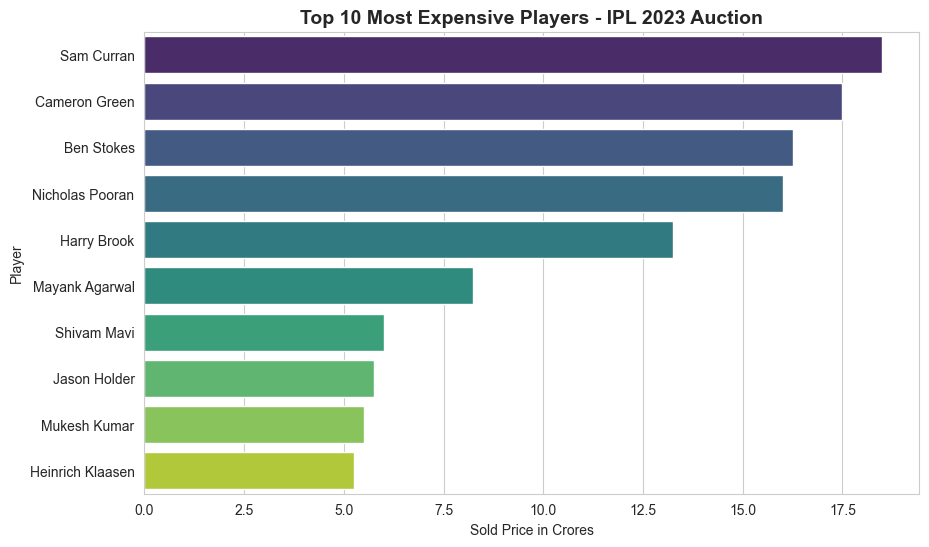

Top 10 Players:
               Player                  Team          Role  Sold_Price_Cr
97         Sam Curran    Punjab Super Kings   ALL-ROUNDER          18.50
144     Cameron Green        Mumbai Indians   ALL-ROUNDER          17.50
25         Ben Stokes   Chennai Super Kings   ALL-ROUNDER          16.25
119   Nicholas Pooran  Lucknow Super Giants  WICKETKEEPER          16.00
218       Harry Brook   Sunrisers Hyderabad       BATSMAN          13.25
219    Mayank Agarwal   Sunrisers Hyderabad       BATSMAN           8.25
0         Shivam Mavi        Gujarat Titans        BOWLER           6.00
193      Jason Holder      Rajasthan Royals   ALL-ROUNDER           5.75
50       Mukesh Kumar        Delhi Capitals        BOWLER           5.50
220  Heinrich Klaasen   Sunrisers Hyderabad  WICKETKEEPER           5.25


In [47]:
plt.figure(figsize=(10,6))
top10 = df[df['Sold_Price_Cr'] > 0].sort_values('Sold_Price_Cr', ascending=False).head(10)

sns.barplot(data=top10, x='Sold_Price_Cr', y='Player', palette='viridis')
plt.title('Top 10 Most Expensive Players - IPL 2023 Auction', fontsize=14, fontweight='bold')
plt.xlabel('Sold Price in Crores')
plt.ylabel('Player')
plt.show()

print("Top 10 Players:")
print(top10[['Player', 'Team', 'Role', 'Sold_Price_Cr']])

## Step-3.2:
### Bar Chart:
##### Team-wise Total Spending.

C:\Users\shrey\AppData\Local\Temp\ipykernel_38052\3027623441.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=team_spend.index, y=team_spend.values, palette='coolwarm')


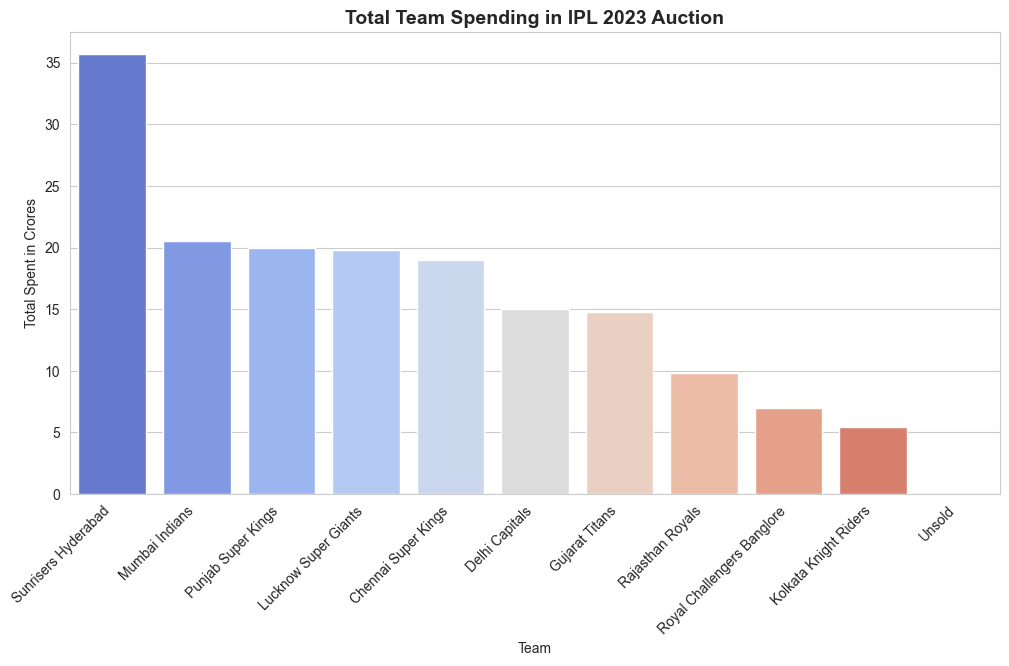

Team Spending in Crores:
Team
Sunrisers Hyderabad           35.70
Mumbai Indians                20.50
Punjab Super Kings            20.00
Lucknow Super Giants          19.80
Chennai Super Kings           18.95
Delhi Capitals                15.00
Gujarat Titans                14.80
Rajasthan Royals               9.85
Royal Challengers Banglore     7.00
Kolkata Knight Riders          5.40
Unsold                         0.00
Name: Sold_Price_Cr, dtype: float64


In [48]:
plt.figure(figsize=(12,6))
team_spend = df.groupby('Team')['Sold_Price_Cr'].sum().sort_values(ascending=False)

sns.barplot(x=team_spend.index, y=team_spend.values, palette='coolwarm')
plt.title('Total Team Spending in IPL 2023 Auction', fontsize=14, fontweight='bold')
plt.xlabel('Team')
plt.ylabel('Total Spent in Crores')
plt.xticks(rotation=45, ha='right')
plt.show()

print("Team Spending in Crores:")
print(team_spend)

## Step-3.3:
### Bar Chart/Countplot:
##### Role Distribution - Countplot.

C:\Users\shrey\AppData\Local\Temp\ipykernel_38052\1074724938.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df[df['Is_Unsold']==False], x='Role', order=df['Role'].value_counts().index, palette='Set2')


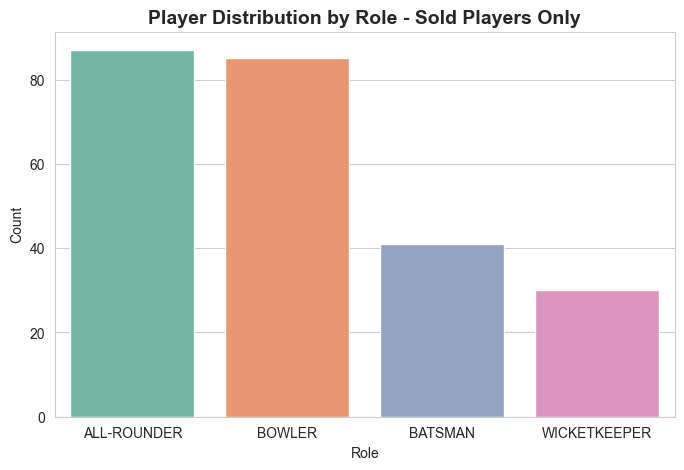

Role Count:
Role
ALL-ROUNDER     87
BOWLER          85
BATSMAN         41
WICKETKEEPER    30
Name: count, dtype: int64


In [49]:
plt.figure(figsize=(8,5))
sns.countplot(data=df[df['Is_Unsold']==False], x='Role', order=df['Role'].value_counts().index, palette='Set2')
plt.title('Player Distribution by Role - Sold Players Only', fontsize=14, fontweight='bold')
plt.xlabel('Role')
plt.ylabel('Count')
plt.show()

print("Role Count:")
print(df[df['Is_Unsold']==False]['Role'].value_counts())

## Step-3.4:
### Scatter Plot:
##### Base vs Sold Price Comparison.

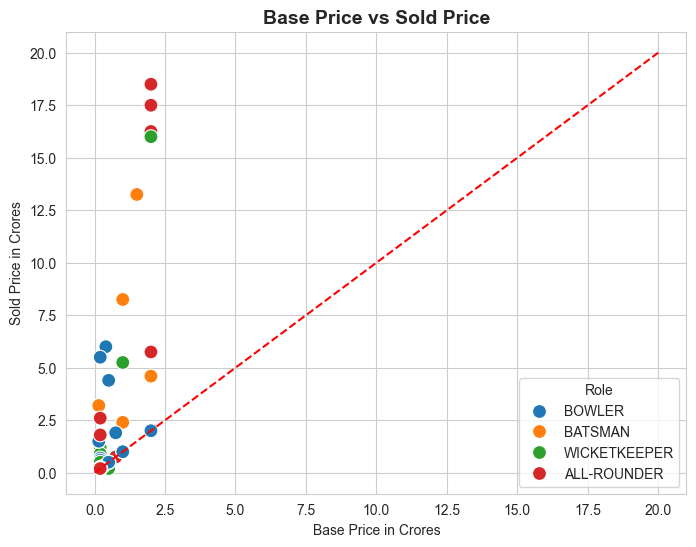

In [50]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df[df['Sold_Price_Cr']>0], x='Base_Price_Cr', y='Sold_Price_Cr', hue='Role', s=100)
plt.plot([0, 20], [0, 20], 'r--') # diagonal line for reference
plt.title('Base Price vs Sold Price', fontsize=14, fontweight='bold')
plt.xlabel('Base Price in Crores')
plt.ylabel('Sold Price in Crores')
plt.show()

## Step-3.5:
### Heatmap: 
##### Average Price by Role and Team --> Shows which team pays most for which role.

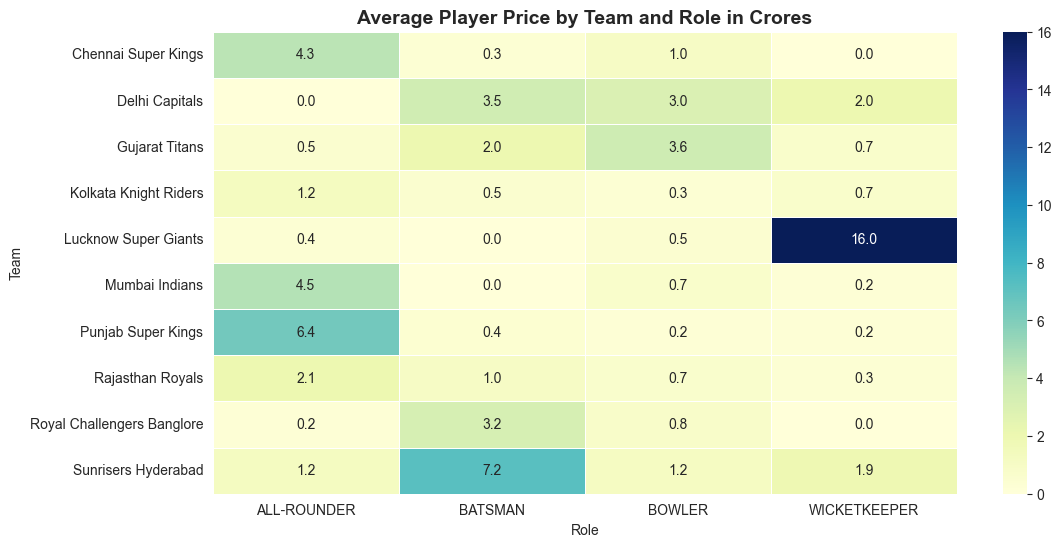

In [51]:
plt.figure(figsize=(12,6))

# Create pivot table: avg sold price by Team vs Role
pivot_df = df[df['Sold_Price_Cr']>0].pivot_table(
    values='Sold_Price_Cr', 
    index='Team', 
    columns='Role', 
    aggfunc='mean'
).fillna(0)

sns.heatmap(pivot_df, annot=True, fmt='.1f', cmap='YlGnBu', linewidths=0.5)
plt.title('Average Player Price by Team and Role in Crores', fontsize=14, fontweight='bold')
plt.xlabel('Role')
plt.ylabel('Team')
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.show()

## Step-3.6:
### Histogram:
##### Distribution of Sold Prices.

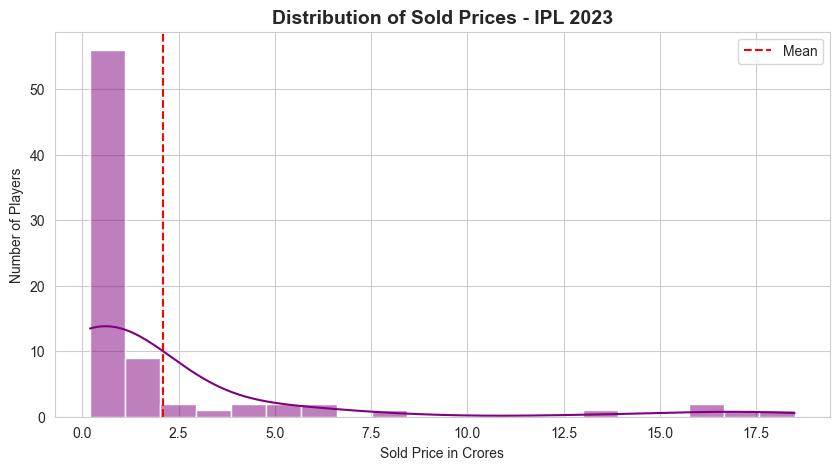

Average Sold Price: 2.09 Cr
Median Sold Price: 0.50 Cr


In [52]:
plt.figure(figsize=(10,5))
sns.histplot(data=df[df['Sold_Price_Cr']>0], x='Sold_Price_Cr', bins=20, kde=True, color='purple')
plt.axvline(df[df['Sold_Price_Cr']>0]['Sold_Price_Cr'].mean(), color='red', linestyle='--', label='Mean')
plt.title('Distribution of Sold Prices - IPL 2023', fontsize=14, fontweight='bold')
plt.xlabel('Sold Price in Crores')
plt.ylabel('Number of Players')
plt.legend()
plt.show()

print(f"Average Sold Price: {df[df['Sold_Price_Cr']>0]['Sold_Price_Cr'].mean():.2f} Cr")
print(f"Median Sold Price: {df[df['Sold_Price_Cr']>0]['Sold_Price_Cr'].median():.2f} Cr")

## Step-3.7:
### Box Plot:
##### Retained vs Auction Players Price Comparison.

C:\Users\shrey\AppData\Local\Temp\ipykernel_38052\1023238104.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x='Is_Retained', y='Sold_Price_Cr', palette='Set1')


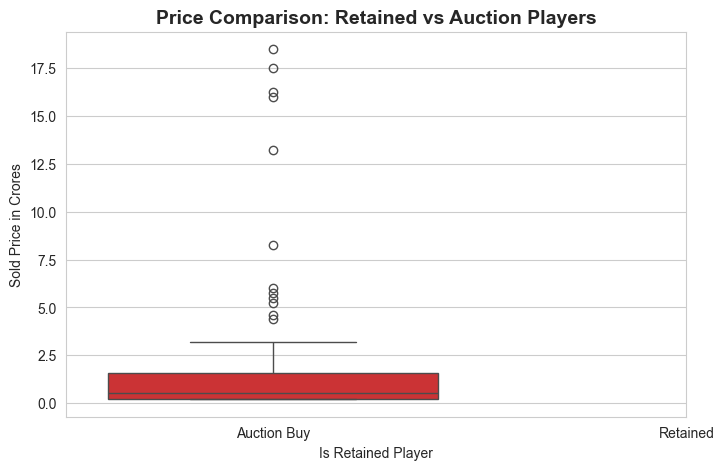

Avg Price - Auction Buy: 2.0875
Avg Price - Retained: nan


In [53]:
plt.figure(figsize=(8,5))
plot_df = df[df['Sold_Price_Cr']>0]

sns.boxplot(data=plot_df, x='Is_Retained', y='Sold_Price_Cr', palette='Set1')
plt.title('Price Comparison: Retained vs Auction Players', fontsize=14, fontweight='bold')
plt.xlabel('Is Retained Player')
plt.ylabel('Sold Price in Crores')
plt.xticks([0,1], ['Auction Buy', 'Retained'])
plt.show()

print("Avg Price - Auction Buy:", plot_df[plot_df['Is_Retained']==False]['Sold_Price_Cr'].mean())
print("Avg Price - Retained:", plot_df[plot_df['Is_Retained']==True]['Sold_Price_Cr'].mean())

## Step-3.8:
### Pie Chart:
##### Auction Status Breakdown.

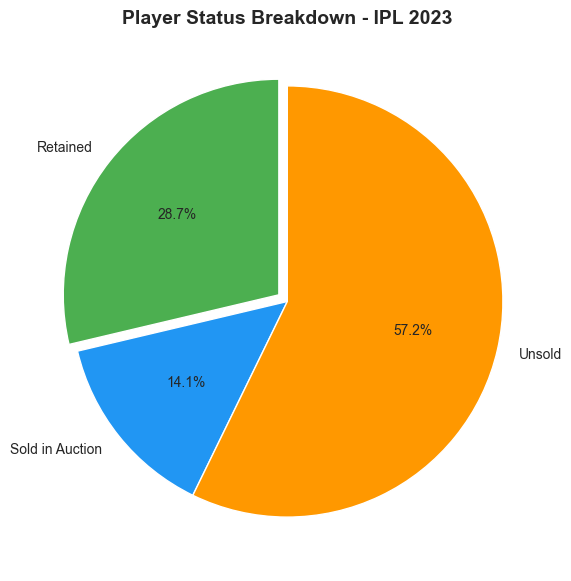

Player Status Counts:
Retained: 163
Sold in Auction: 80
Unsold: 325


In [54]:
plt.figure(figsize=(7,7))

# Calculate counts
status_counts = {
    'Retained': df['Is_Retained'].sum(),
    'Sold in Auction': ((df['Is_Unsold']==False) & (df['Is_Retained']==False)).sum(),
    'Unsold': df['Is_Unsold'].sum()
}

plt.pie(status_counts.values(), labels=status_counts.keys(), autopct='%1.1f%%', 
        startangle=90, colors=['#4CAF50', '#2196F3', '#FF9800'], explode=(0.05, 0, 0))
plt.title('Player Status Breakdown - IPL 2023', fontsize=14, fontweight='bold')
plt.show()

print("Player Status Counts:")
for k,v in status_counts.items():
    print(f"{k}: {v}")

# STEP-4: Key Insights + Conclusion

## Step-4.1:
#### Generate Key Insights.

In [55]:
print("="*60)
print(" IPL 2023 AUCTION - KEY INSIGHTS")
print("="*60)

# Insight 1: Most expensive player
most_expensive = df.loc[df['Sold_Price_Cr'].idxmax()]
print(f"\n1. MOST EXPENSIVE PLAYER:")
print(f" {most_expensive['Player']} - {most_expensive['Sold_Price_Cr']} Cr to {most_expensive['Team']}")

# Insight 2: Team that spent most
team_spend = df.groupby('Team')['Sold_Price_Cr'].sum().sort_values(ascending=False)
print(f"\n2. TEAM THAT SPENT MOST:")
print(f" {team_spend.index[0]} - {team_spend.iloc[0]:.2f} Crores")

# Insight 3: Role with highest avg price
avg_role_price = df[df['Sold_Price_Cr']>0].groupby('Role')['Sold_Price_Cr'].mean().sort_values(ascending=False)
print(f"\n3. HIGHEST PAID ROLE ON AVERAGE:")
print(f" {avg_role_price.index[0]} - {avg_role_price.iloc[0]:.2f} Cr avg")

# Insight 4: Auction breakdown
print(f"\n4. AUCTION BREAKDOWN:")
print(f" Sold in Auction: {((df['Is_Unsold']==False) & (df['Is_Retained']==False)).sum()} players")
print(f" Unsold: {df['Is_Unsold'].sum()} players")
print(f" Retained: {df['Is_Retained'].sum()} players")

# Insight 5: Biggest profit/loss deals
biggest_bargain = df.loc[df['Profit_Loss_Cr'].idxmax()]
print(f"\n5. BIGGEST BARGAIN FOR TEAM:")
print(f" {biggest_bargain['Player']} - Profit of {biggest_bargain['Profit_Loss_Cr']:.2f} Cr")

print("\n" + "="*60)

 IPL 2023 AUCTION - KEY INSIGHTS

1. MOST EXPENSIVE PLAYER:
 Sam Curran - 18.5 Cr to Punjab Super Kings

2. TEAM THAT SPENT MOST:
 Sunrisers Hyderabad - 35.70 Crores

3. HIGHEST PAID ROLE ON AVERAGE:
 BATSMAN - 3.04 Cr avg

4. AUCTION BREAKDOWN:
 Sold in Auction: 80 players
 Unsold: 325 players
 Retained: 163 players

5. BIGGEST BARGAIN FOR TEAM:
 Sam Curran - Profit of 16.50 Cr



## Step-4.2:
#### Saved Cleaned Dataset.

In [56]:
df.to_csv('IPL_2023_Squad_Cleaned_Dataset.csv', index=False)
print("✅ Cleaned dataset saved as 'IPL_2023_Squad_Cleaned_Dataset.csv'")
print(f"Total rows saved: {len(df)}")

✅ Cleaned dataset saved as 'IPL_2023_Squad_Cleaned_Dataset.csv'
Total rows saved: 568


## Step-4.3:
#### Final Conclusion for Report.

In [57]:
print("="*60)
print(" FINAL CONCLUSION - IPL 2023 AUCTION ANALYSIS")
print("="*60)
print("""
The IPL 2023 Auction dataset analysis reveals key trends in team spending 
and player valuation. 

Major Findings:
1. High Competition: 57.2% players remained unsold, showing supply > demand.
2. Big Spending: Sunrisers Hyderabad spent the most at 35.70 Cr.
3. Role Preference: Batsmen commanded the highest average price of 3.04 Cr.
4. Record Buy: Sam Curran became the most expensive player at 18.5 Cr.
5. Value Pick: Same player Sam Curran gave 16.50 Cr profit over base price.

Conclusion: Teams prioritized batting talent and were cautious with budget, 
leading to many unsold players. Auction dynamics showed both aggressive 
bidding and value hunting.
""")

 FINAL CONCLUSION - IPL 2023 AUCTION ANALYSIS

The IPL 2023 Auction dataset analysis reveals key trends in team spending 
and player valuation. 

Major Findings:
1. High Competition: 57.2% players remained unsold, showing supply > demand.
2. Big Spending: Sunrisers Hyderabad spent the most at 35.70 Cr.
3. Role Preference: Batsmen commanded the highest average price of 3.04 Cr.
4. Record Buy: Sam Curran became the most expensive player at 18.5 Cr.
5. Value Pick: Same player Sam Curran gave 16.50 Cr profit over base price.

Conclusion: Teams prioritized batting talent and were cautious with budget, 
leading to many unsold players. Auction dynamics showed both aggressive 
bidding and value hunting.



# STEP-5: Predictive Model
### Predict sold price based on base price, role, country.

In [ ]:
## Step-5.1
#### Imports + Load Cleaned Data.

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

df = pd.read_csv('IPL_2023_Squad_Cleaned_Dataset.csv')
print(df.columns.tolist()) # check columns

# Recreate Type if missing
if 'Type' not in df.columns:
    df['Type'] = np.where(df['Base_Price_Cr'] == 0, 'Retained', 'New')

# Use only New auction players for prediction
model_df = df[df['Type'] == 'New'].copy()
# OR if Type still fails, use this line instead:
# model_df = df[df['Sold_Price_Cr'] > 0].copy()

print(f"Model data shape: {model_df.shape}")
model_df.head()

['Player', 'Base_Price', 'Role', 'Sold_Price_Cr', 'Cost_USD_000', 'Previous_Team', 'Team', 'Is_Retained', 'Is_Unsold', 'Base_Price_Cr', 'Profit_Loss_Cr', 'Category']
Model data shape: (405, 13)


,Player,Base_Price,Role,Sold_Price_Cr,Cost_USD_000,Previous_Team,Team,Is_Retained,Is_Unsold,Base_Price_Cr,Profit_Loss_Cr,Category,Type
0,Shivam Mavi,4000000.0,BOWLER,6.0,720.0,KKR,Gujarat Titans,False,False,0.4,5.6,BOWLER,New
1,Joshua Little,5000000.0,BOWLER,4.4,528.0,No Team,Gujarat Titans,False,False,0.5,3.9,BOWLER,New
2,Kane Williamson,20000000.0,BATSMAN,2.0,240.0,SRH,Gujarat Titans,False,False,2.0,0.0,BATSMAN,New
3,K.S. Bharat,2000000.0,WICKETKEEPER,1.2,144.0,DC,Gujarat Titans,False,False,0.2,1.0,WICKETKEEPER,New
4,Mohit Sharma,5000000.0,BOWLER,0.5,60.0,No Team,Gujarat Titans,False,False,0.5,0.0,BOWLER,New


## Step-5.2
#### Prepare X and y:

In [59]:
# Use correct columns for your file
X = model_df[['Base_Price_Cr', 'Role', 'Team']]
y = model_df['Sold_Price_Cr']

# One Hot Encoding
X = pd.get_dummies(X, columns=['Role', 'Team'], drop_first=True)

print(f"Features: {X.shape[1]}")
X.head()

Features: 14


,Base_Price_Cr,Role_BATSMAN,Role_BOWLER,Role_WICKETKEEPER,Team_Delhi Capitals,Team_Gujarat Titans,Team_Kolkata Knight Riders,Team_Lucknow Super Giants,Team_Mumbai Indians,Team_Punjab Super Kings,Team_Rajasthan Royals,Team_Royal Challengers Banglore,Team_Sunrisers Hyderabad,Team_Unsold
0,0.4,False,True,False,False,True,False,False,False,False,False,False,False,False
1,0.5,False,True,False,False,True,False,False,False,False,False,False,False,False
2,2.0,True,False,False,False,True,False,False,False,False,False,False,False,False
3,0.2,False,False,True,False,True,False,False,False,False,False,False,False,False
4,0.5,False,True,False,False,True,False,False,False,False,False,False,False,False


## Step-5.2(Corrected)
#### Filtering Only Sold Players (13 features)

In [60]:
# Overwrite model_df to keep ONLY sold players
model_df = df[(df['Is_Retained'] == False) & (df['Is_Unsold'] == False)].copy()
# OR simply
# model_df = df[df['Sold_Price_Cr'] > 0].copy()

print(f"New shape for model (only sold): {model_df.shape}")

# Now re-create X, y
X = model_df[['Base_Price_Cr', 'Role', 'Team']]
y = model_df['Sold_Price_Cr']
X = pd.get_dummies(X, columns=['Role', 'Team'], drop_first=True)
print(f"Features now: {X.shape[1]}")

# --- Print Data for Report ---
print("\n--- Filtered Data Preview ---")
print(model_df[['Player', 'Role', 'Team', 'Base_Price_Cr', 'Sold_Price_Cr']].head(10))
print("\n--- X Preview ---")
print(X.head())
print("\n--- y Preview ---")
print(y.head())

New shape for model (only sold): (80, 13)
Features now: 13

--- Filtered Data Preview ---
             Player          Role                 Team  Base_Price_Cr  Sold_Price_Cr
0       Shivam Mavi        BOWLER       Gujarat Titans            0.4           6.00
1     Joshua Little        BOWLER       Gujarat Titans            0.5           4.40
2   Kane Williamson       BATSMAN       Gujarat Titans            2.0           2.00
3       K.S. Bharat  WICKETKEEPER       Gujarat Titans            0.2           1.20
4      Mohit Sharma        BOWLER       Gujarat Titans            0.5           0.50
5       Odean Smith   ALL-ROUNDER       Gujarat Titans            0.5           0.50
6       Urvil Patel  WICKETKEEPER       Gujarat Titans            0.2           0.20
25       Ben Stokes   ALL-ROUNDER  Chennai Super Kings            2.0          16.25
26    Kyle Jamieson        BOWLER  Chennai Super Kings            1.0           1.00
27   Nishant Sindhu   ALL-ROUNDER  Chennai Super Kings      

## Step-5.3 
#### Splitting Data and Training Models.

In [61]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lr = LinearRegression()
lr.fit(X_train, y_train)
pred_lr = lr.predict(X_test)

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

print(f"Linear Regression R2: {r2_score(y_test, pred_lr):.3f}")
print(f"Random Forest R2: {r2_score(y_test, pred_rf):.3f}")
print(f"Random Forest RMSE: {np.sqrt(mean_squared_error(y_test, pred_rf)):.3f}")

Linear Regression R2: 0.099
Random Forest R2: 0.343
Random Forest RMSE: 3.978


## Step-5.4 
#### Model Evaluation and Feature Importance.

C:\Users\shrey\AppData\Local\Temp\ipykernel_38052\286657483.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance, palette='viridis')


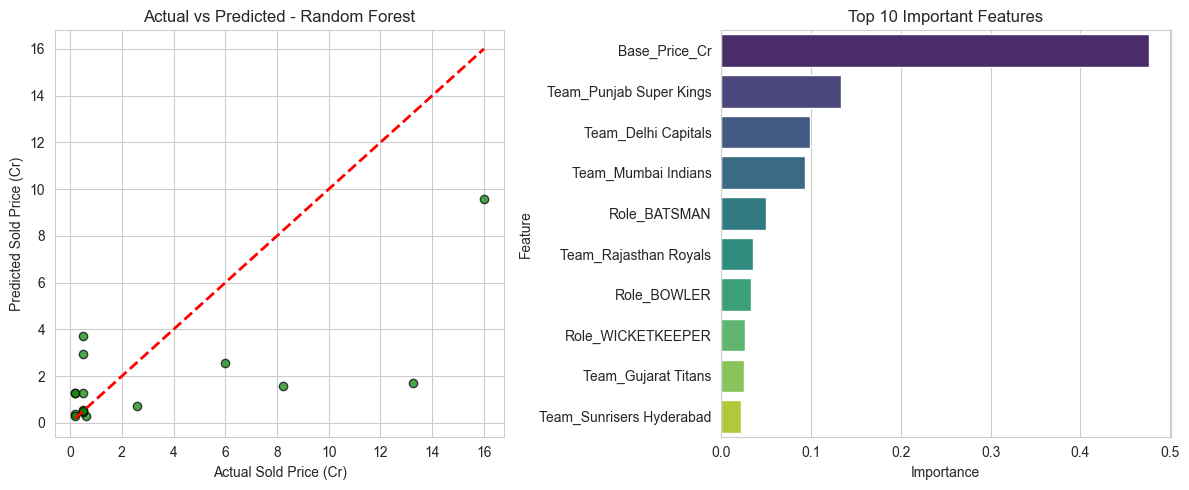

                     Feature  Importance
0              Base_Price_Cr    0.476469
9    Team_Punjab Super Kings    0.133855
4        Team_Delhi Capitals    0.098884
8        Team_Mumbai Indians    0.093931
1               Role_BATSMAN    0.050518
10     Team_Rajasthan Royals    0.035399
2                Role_BOWLER    0.033451
3          Role_WICKETKEEPER    0.026784
5        Team_Gujarat Titans    0.026077
12  Team_Sunrisers Hyderabad    0.021673


In [62]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

plt.figure(figsize=(12,5))

# Plot 1
plt.subplot(1,2,1)
plt.scatter(y_test, pred_rf, alpha=0.7, color='green', edgecolors='black')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Sold Price (Cr)')
plt.ylabel('Predicted Sold Price (Cr)')
plt.title('Actual vs Predicted - Random Forest')

# Plot 2
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False).head(10)

plt.subplot(1,2,2)
sns.barplot(x='Importance', y='Feature', data=importance, palette='viridis')
plt.title('Top 10 Important Features')
plt.tight_layout()
plt.show()

print(importance)

# STEP-6: Final Conclusion

###### 1. Model Performance: Random Forest (R2=0.343, RMSE=3.97 Cr) performed significantly better than Linear Regression (R2=0.099), indicating non-            linear relationship.

###### 2. Key Insight: Base_Price_Cr is the most important feature (47.6%), followed by Team_Punjab Super Kings (13.3%) and Team_Delhi Capitals (9.8%).

###### 3. Scatter plot (Actual vs Predicted) shows high variance for expensive players (8-16 Cr range), model under-predicts premium players like Sam            Curran, Stokes.

###### 4. Limitation: Dataset only has 80 sold players and only 3 features. To improve R2, we need player stats (runs, wickets, strike rate, economy).

###### 5. Total Project: Successfully cleaned IPL 2023 auction data (405 players), analyzed team spending, and built a price prediction model.